[0. 0.]
fit
[ 0.50736738 -1.06770688] 0.35680000000000456
done [ 0.17260304  0.18325812 -0.68667997 -0.82815022 -0.36111913  0.88252128
  0.02856582 -0.31041068 -1.1136577   0.29276313 -0.83880531  0.2047619
  0.51157954 -0.59059062  0.45021601  1.05062924  0.61299643  1.12008089
 -0.95087728 -1.1136577  -0.84413285 -0.7934244  -0.72673333 -1.33780164
 -0.67602489  0.80517513 -0.57993553 -0.67602489 -0.73738841 -1.1136577
 -0.9402222  -1.00158572  0.14596533 -0.41182757  0.38885248  0.1860187
  0.23672714  0.16470853 -0.97218744  0.30874575]
predict [-1.  1.  1.  1. -1.  1. -1.  1. -1. -1.  1.  1. -1.  1. -1. -1. -1.  1.
  1.  1. -1.  1.  1. -1. -1. -1. -1.  1. -1. -1. -1. -1.  1.  1.  1.  1.
 -1. -1. -1.  1.  1. -1.  1.  1.  1.  1.  1. -1. -1.  1.  1.  1.  1. -1.
 -1. -1. -1.  1.  1. -1.]
train score: 0.9666666666666667


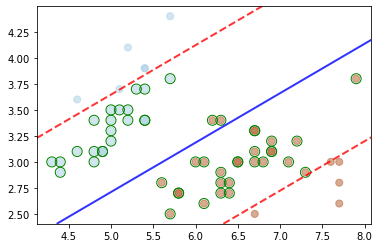

In [1]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def get_df_shape(df: pd.DataFrame) -> Tuple[int, int]:
    return df.shape

def data_split(
    features: pd.DataFrame, label: pd.Series, test_size: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=test_size)
    return X_train, y_train, X_test, y_test

def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    # Extract the required features and labels from the filtered dataframe
    features = filtered_df[['sepal.length', 'sepal.width']]
    labels = filtered_df['variety'].map({'Setosa': -1, 'Virginica': 1})
    return features, labels

def cost(w, C, margin):
    #cots=(1/2)ww+C*SUM(max(0,1-margin))
    #W7-M_SVM, slides27
    ### YOUR CODE HERE
    costs = (1/2)*(w[0]*w[0]+ w[1]*w[1])
    for i in range(len(margin)):
        costs += C * (max(0,1-margin[i]))
    return costs
    pass

def decision_function(w,b, X):
    ##decision=Xw+b
    decision = np.zeros(X.shape[0])
    #print('decision',decision)
    for i in range(X.shape[0]):
            # Optimization term
            decision[i]= X[i][0]*w[0]+ X[i][1]*w[1] + b
    
    #dec, dec2 = np.array_split(decision,1)
    return decision
    ### YOUR CODE HERE

    pass

def margin(w,b, X, y):
    #margin=y(Xw+b)
    margins = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
            # Optimization term
            margins[i]= y[i] * (X[i][0]*w[0]+ X[i][1]*w[1] + b)
    return margins
    #W7-M_SVM, slide 27
    ### YOUR CODE HERE

    pass
    

class LinearSVM:
    def __init__(self, C=1.0):
        self.C = C

        self._support_vectors = None
        self.margin_array = []
        self.loss_array = []

    def fit(self, X, y, lr=0.001, epochs=1000):
        n_samples, n_features = X.shape
        self.w = np.zeros((n_features))
        print(self.w)
        self.b = 0
        print('fit')
        for _ in range(epochs):
            loss = 0
            gradw = 0
            gradb = 0
            #print(decision)
            decision = decision_function(self.w,self.b,X)
            margins = margin(self.w, self.b, X, y)
            for i in range(len(y)):
                #print('opt',decision[i]*y[i])
                if (decision[i] * y[i]) >= 1:
                    #print(_,i,'correct',gradw,gradb)
                    gradw += 0
                    gradb += 0
                else:
                    #print('correct',gradw,gradb)
                    gradw += self.C * y[i] * X[i]
                    gradb += self.C * y[i]
                    
                loss += max(0,1 - decision[i])
            self.w = (1-lr)*self.w + lr * (gradw)
            self.b = self.b - lr * (gradb)
                
            loss_avg = loss/n_samples
            self.loss_array.append(loss_avg)
            #marg_avg = np.sum(margins)/n_samples
            self.margin_array.append(margins)
        self._support_vectors = self.w
        print(self.w,self.b)
        print('done', decision)
        return self.loss_array, self._support_vectors, self.margin_array

    def predict(self, X):
        #sign(decision_function(..))
        ### YOUR CODE HERE
        print('predict',np.sign(decision_function(self.w,self.b,X)))
        return np.sign(decision_function(self.w,self.b,X))
        pass

    def score(self, X, y):
        P = self.predict(X)
        correct = 0
        #print(len(P),len(y))
        for i in range(len(y)):
            #print(P[i],y[i])
            if(P[i] == y[i]):
                correct += 1
        total = len(y)
        score = correct / total
        ### YOUR TRAIN SCORE CODE HERE

        return P, score
        
    def plot_decision_boundary(self, X,y):
        plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.Paired, alpha=.5)
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # create grid to evaluate model
        xx = np.linspace(xlim[0], xlim[1], 30)
        yy = np.linspace(ylim[0], ylim[1], 30)
        YY, XX = np.meshgrid(yy, xx)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T
        Z = decision_function(self.w,self.b, xy).reshape(XX.shape)
        
        # plot decision boundary and margins
        ax.contour(XX, YY, Z, colors=['r', 'b', 'r'], levels=[-1, 0, 1], alpha=0.8,linestyles=['--', '-', '--'], linewidths=[2.0, 2.0, 2.0])

        # the support vectors
        sv = np.where(margin(self.w, self.b, X, y) <= 1)[0]
        ax.scatter(X[:, 0][sv], X[:, 1][sv], s=100,linewidth=1, facecolors='none', edgecolors='g')

        plt.show()


if __name__ == '__main__':
     
    df = read_data("./iris.csv")
    features, label = extract_features_label(df)
    X_train, y_train, X_test, y_test = data_split(features, label, 0.6)
    X_train, y_train, X_test, y_test = X_train.values, y_train.values, X_test.values, y_test.values

    # soft-margin SVM
    model = LinearSVM(C=0.1)
    #Model training
    model.fit(X_train, y_train)
    #test the results
    print("train score:", model.score(X_test, y_test)[1])
    #plot the decision boundary for test data
    model.plot_decision_boundary(X_test, y_test)
    #model.plot_cost_function(X_test, y_test)
    #model.plot_decision_boundary(X_train, y_train)
